In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [2]:
processing = 'raw'

# load observations
obs_dfs = {}
for var in ['temp','precip','streamflow']:
    seasonal_dfs = []
    for season in ['winter','spring','summer','autumn']:
        df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/'+var+'/'+var+'_obs_'+season+'_'+processing+'.csv')
        seasonal_dfs.append(df)
        
    var_df = pd.concat(seasonal_dfs,axis=0)
    var_df['date'] = pd.to_datetime(var_df['date'])
    var_df = var_df.set_index('date').sort_index()
    if var == 'streamflow':
        var_df = var_df.drop('36001',axis=1)
        
    obs_dfs[var] = var_df
'''
# load station-based model data
model_direc = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/'+processing+'/'
model_dfs = {}
for var in ['TA','PRECIPI','ROF']:
    seasonal_dfs = []
    for season in ['winter','spring','summer','autumn']:
        df = pd.read_csv(model_direc+var+"/seasonal/station_resolution/"+var+'_d4PDF_HPB_ensMean_gaussian_'+season+'_1951-2021.csv')
        seasonal_dfs.append(df)
        
    var_df = pd.concat(seasonal_dfs,axis=0)
    var_df['time'] = pd.to_datetime(var_df['time'])
    var_df = var_df.set_index('time').sort_index()
    if var == 'ROF':
        var_df = var_df.drop('36001',axis=1)
    
    model_dfs[var] = var_df    
'''
# load temp/precip station metadata
temp_meta_df = pd.read_csv('/home/queenle/hydro_attribution/station_data/temperature_17_series/17SS_meta.csv')
temp_meta_df.loc[6,'LONGT']=176.9 #slightly shift Napier so its nearest neighbor is not an ocean cell

precip_meta_df = pd.read_csv('/home/queenle/hydro_attribution/station_data/rainfall_21_series/rainfall_stns.csv')
precip_meta_df.loc[4,'LONGT']=176.9 #slightly shift Napier so its nearest neighbor is not an ocean cell
precip_meta_df.loc[5,'LONGT']=175.25 #slightly shift Napier so its nearest neighbor is not an ocean cell

# load streamflow metadata
streamflow_meta_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
streamflow_meta_df.set_index('Number',inplace=True)
streamflow_meta_df = streamflow_meta_df.loc[[int(s) for s in obs_dfs['streamflow'].columns]]
streamflow_meta_df.sort_values('gauge_lat', ascending = False, inplace=True)
streamflow_meta_df['number_label'] = np.arange(1,len(streamflow_meta_df)+1)
streamflow_meta_df['number_copy'] = streamflow_meta_df.index.values.tolist()


In [70]:
test = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/ROF/full/catchment_resolution/ROF_d4PDF_HPB_m001_raw_winter_1951-2021.csv')
test = test.set_index('time').drop('Unnamed: 0',axis=1)

In [71]:
model_ts = test['71132']
model_ts

time
1951-06-01    0.000049
1952-06-01    0.000047
1953-06-01    0.000053
1954-06-01    0.000037
1955-06-01    0.000045
                ...   
2017-06-01    0.000062
2018-06-01    0.000061
2019-06-01    0.000035
2020-06-01    0.000045
2021-06-01    0.000063
Name: 71132, Length: 71, dtype: float64

In [81]:
# obs conversions
obs_ts = obs_dfs['streamflow']['71132']['1951':'2019']
obs_ts = obs_ts.loc[(obs_ts.index.month == 6)]
area_m2 = streamflow_meta_df.loc[71132]['area_km2']*1e6

obs_ts = obs_ts / 1000 # m3/s
obs_ts = obs_ts / area_m2 # m/s
obs_ts = obs_ts * 1000 * 86400 # mm/day

# model conversions
model_ts = test['71132']['1951':'2019']
model_ts = model_ts * 86400



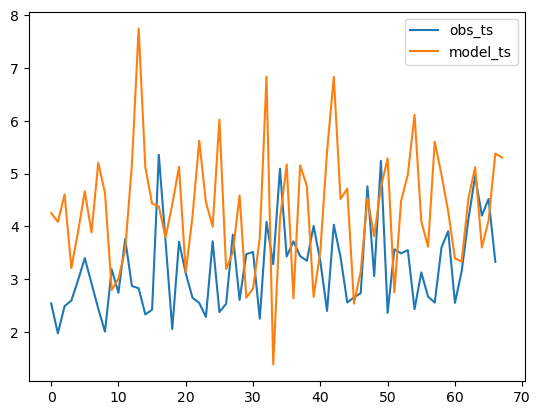

In [83]:
plt.plot(obs_ts.values,label='obs_ts')
plt.plot(model_ts.values,label='model_ts')

plt.legend()

In [75]:
obs_ts

date
1932-06-01    1.344396e+12
1933-06-01    3.611058e+12
1934-06-01    3.133308e+12
1935-06-01    2.816939e+12
1936-06-01    2.539550e+12
                  ...     
2015-06-01    4.206280e+12
2016-06-01    4.522432e+12
2017-06-01    3.329246e+12
2018-06-01             NaN
2019-06-01             NaN
Name: 71132, Length: 88, dtype: float64

In [76]:
model_ts

time
1951-06-01    4.255018
1952-06-01    4.087474
1953-06-01    4.605351
1954-06-01    3.211476
1955-06-01    3.901009
                ...   
2017-06-01    5.381367
2018-06-01    5.305972
2019-06-01    3.002991
2020-06-01    3.869337
2021-06-01    5.422878
Name: 71132, Length: 71, dtype: float64

In [44]:
'''
unit should be L/s
'''

confirmed
[93203,46618,]

'Awanui at School Cut'

In [49]:
for site in means.index:
    name = streamflow_meta_df.loc[int(site)]['Name']
    print(f'{means[site]:.2f} ({site} - {name})')

83574.73 (71132 - Lake Tekapo at Power Station Intake)
9514.61 (46618 - Mangakahia at Gorge)
94624.51 (64602 - Waiau at Marble Point)
8133.92 (71135 - Jollie at Mt Cook Stn)
18370.97 (77505 - Mataura at Parawa)
89331.62 (16501 - Motu at Houpoto)
11416.16 (1043427 - Mangakino at Dillon Rd)
80489.18 (71120 - Lake Ohau at Lake Middleton)
3178.58 (71129 - Forks at Balmoral)
22642.52 (62103 - Acheron at Clarence)
6111.52 (1316 - Awanui at School Cut)
8062.60 (46651 - Manganui at Permanent Station)
34769.22 (33316 - Ongarue at Taringamotu)
37591.91 (9205 - Waihou at Te Aroha Br)
3211.87 (68001 - Selwyn at Whitecliffs)
14936.38 (32503 - Manawatu at Weber Rd)
2021.31 (78625 - Otapiri at Otapiri Gorge)
664.74 (60104 - Taylor at Borough Weir)
197034.13 (75292 - Lake Wanaka at Roys Bay)
445.84 (3506 - Maungaparerua at Tyrees Ford)
3645.86 (43472 - Waiotapu at Reporoa)
4594.59 (1043428 - Tahunaatara at Ohakuri Rd)
698.09 (73501 - Leith at University Foot Br)
27025.29 (60114 - Wairau at Dip Flat)
2

In [55]:
site = obs_dfs['streamflow']['46618']
site.loc[(site.index.month == 12)].mean()/1000

5.666940797725203

In [34]:
means = obs_dfs['streamflow'].mean(axis=0)

In [12]:
time_windows = {'TA':['1951','2020'],'temp':['1951','2020'],
                'PRECIPI':['1951','2020'],'precip':['1951','2020'],
                'ROF':['1969','2019'],'streamflow':['1969','2019']
               }

vrs_dict = {'temperature':['temp','TA'],
            'precipitation':['precip','PRECIPI'],
            'streamflow':['streamflow','ROF']}

season_dict = {6:'Winter',9:'Spring',12:'Summer',3:'Autumn'}

vlim_dict = {'TA':0.03,
             'temp':0.03,
             'PRECIPI':0.004,
             'precip':0.01,
             'ROF':0.005,
             'streamflow':30
            }

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

In [4]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

In [6]:
def get_trend_info(var,df):
    
    lats = []
    lons = []
    slopes = []

    for site in df:

        ts = df[site].dropna()

        slopes.append(np.polyfit([i for i in range(len(ts))],ts,deg=1)[0])
        
        if var == 'precip' or var == 'PRECIPI':
            lats.append(precip_meta_df.loc[precip_meta_df['station'] == site]['LAT'].values[0])
            lons.append(precip_meta_df.loc[precip_meta_df['station'] == site]['LONGT'].values[0])
            
        elif var == 'temp' or var == 'TA':
            lats.append(temp_meta_df.loc[temp_meta_df['station'] == site]['LAT'].values[0])
            lons.append(temp_meta_df.loc[temp_meta_df['station'] == site]['LONGT'].values[0])
            
        elif var == 'streamflow' or var == 'ROF':
            lats.append((streamflow_meta_df.loc[int(site)]['centroid_lat']))
            lons.append(streamflow_meta_df.loc[int(site)]['centroid_lon'])
            
    return(lats,lons,slopes)

In [5]:
def get_mean_info(var,df):
    
    lats = []
    lons = []
    means = []

    for site in df:

        ts = df[site].dropna()

        means.append(ts.mean())
        
        if var == 'precip' or var == 'PRECIPI':
            lats.append(precip_meta_df.loc[precip_meta_df['station'] == site]['LAT'].values[0])
            lons.append(precip_meta_df.loc[precip_meta_df['station'] == site]['LONGT'].values[0])
            
        elif var == 'temp' or var == 'TA':
            lats.append(temp_meta_df.loc[temp_meta_df['station'] == site]['LAT'].values[0])
            lons.append(temp_meta_df.loc[temp_meta_df['station'] == site]['LONGT'].values[0])
            
        elif var == 'streamflow' or var == 'ROF':
            lats.append((streamflow_meta_df.loc[int(site)]['centroid_lat']))
            lons.append(streamflow_meta_df.loc[int(site)]['centroid_lon'])
            
    return(lats,lons,means)

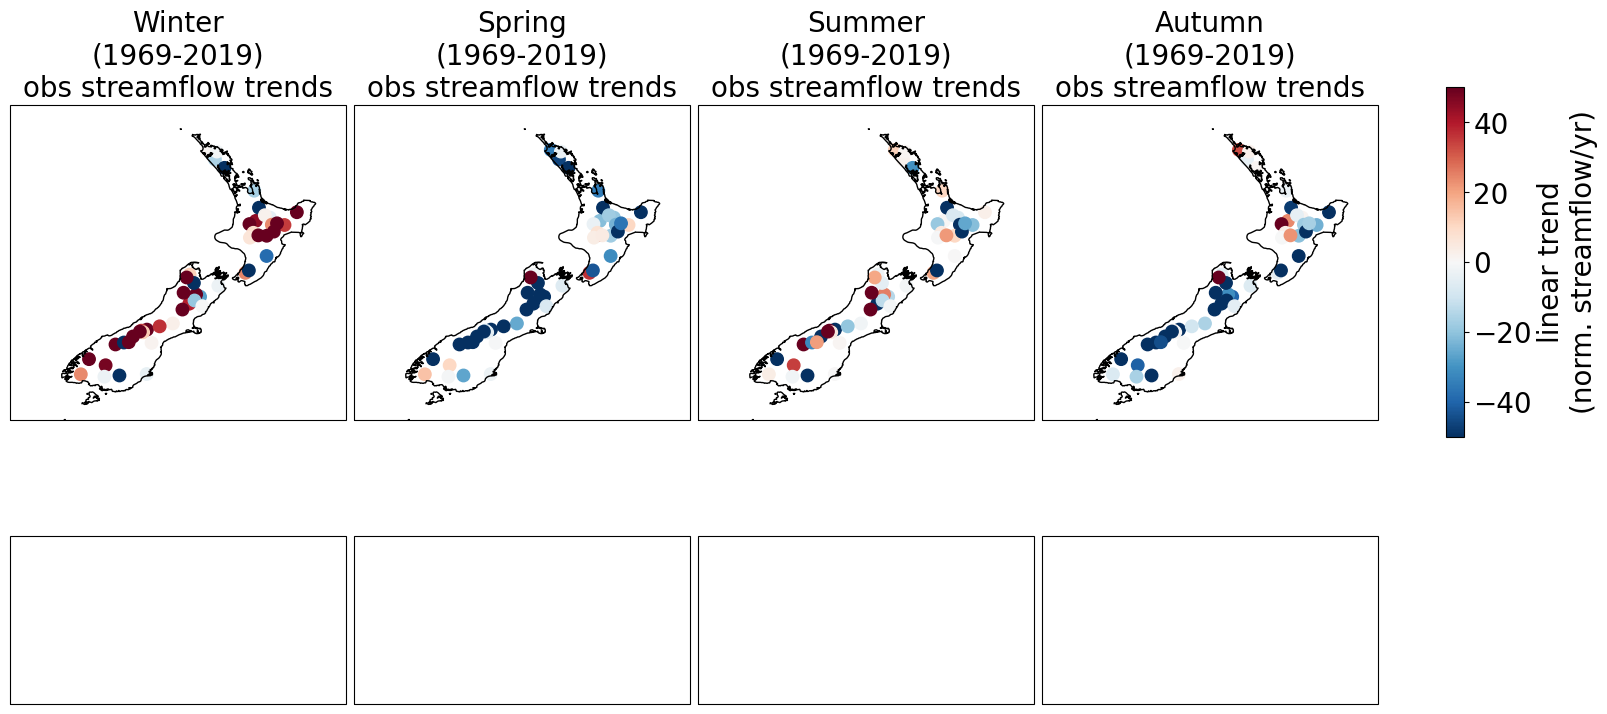

In [15]:
vlim_dict['streamflow'] = 50

fig,axs = plt.subplots(2,4,figsize=(16,8),subplot_kw=dict(projection=ccrs.PlateCarree()),layout="constrained")

v = 'streamflow'
vrs = vrs_dict[v]

for i,df_dict in enumerate([obs_dfs]):
    
    var  = vrs[i]
    
    for j,season in enumerate([6,9,12,3]):
        
        ax = axs[i][j]
        
        df = df_dict[var]
        df = df.loc[(df.index.month == season)][time_windows[var][0]:time_windows[var][1]]
        
        lats, lons, slopes = get_trend_info(var,df)
        
        im = ax.scatter(lons,lats,c=slopes,cmap='RdBu_r',marker='o',s=80,vmin=-vlim_dict[var],vmax=vlim_dict[var])

        ax.coastlines()
        ax.add_feature(cf.BORDERS)
        ax.set_extent([164,180, -48,-33])#, crs=noproj)
        
        if i == 0:
            ax.set_title(season_dict[season] + '\n(' + time_windows[var][0] + '-' + time_windows[var][1] + ')\nobs ' + var + ' trends',fontsize=20)
        else:
            ax.set_title('model ' + var + ' trends',fontsize=20)


        if j == 3:
            cbar = fig.colorbar(im, ax=axs[i,:])
            cbar.set_label(label='linear trend\n(norm. '+var+'/yr)',size=20)
            cbar.ax.tick_params(labelsize=20)
            
#plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/obs_v_model_'+v+'_trend_maps.png',dpi=300)

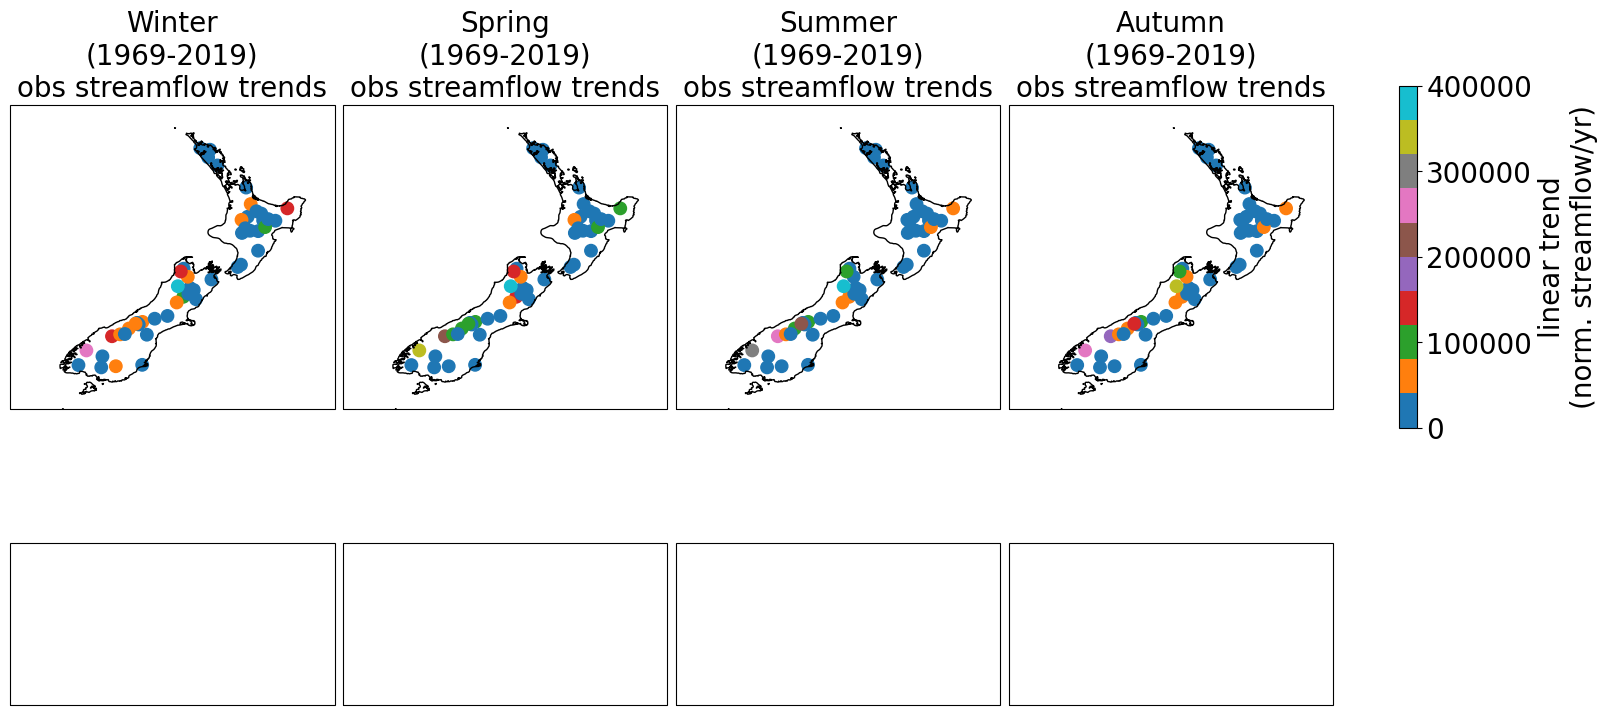

In [23]:
vlim_dict['streamflow'] = 400000


fig,axs = plt.subplots(2,4,figsize=(16,8),subplot_kw=dict(projection=ccrs.PlateCarree()),layout="constrained")

v = 'streamflow'
vrs = vrs_dict[v]

for i,df_dict in enumerate([obs_dfs]):
    
    var  = vrs[i]
    
    for j,season in enumerate([6,9,12,3]):
        
        ax = axs[i][j]
        
        df = df_dict[var]
        df = df.loc[(df.index.month == season)][time_windows[var][0]:time_windows[var][1]]
        
        lats, lons, means = get_mean_info(var,df)
        
        im = ax.scatter(lons,lats,c=means,cmap='tab10',marker='o',s=80,vmin=0,vmax=vlim_dict[var])

        ax.coastlines()
        ax.add_feature(cf.BORDERS)
        ax.set_extent([164,180, -48,-33])#, crs=noproj)
        
        if i == 0:
            ax.set_title(season_dict[season] + '\n(' + time_windows[var][0] + '-' + time_windows[var][1] + ')\nobs ' + var + ' trends',fontsize=20)
        else:
            ax.set_title('model ' + var + ' trends',fontsize=20)


        if j == 3:
            cbar = fig.colorbar(im, ax=axs[i,:])
            cbar.set_label(label='linear trend\n(norm. '+var+'/yr)',size=20)
            cbar.ax.tick_params(labelsize=20)
            
#plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/obs_v_model_'+v+'_trend_maps.png',dpi=300)

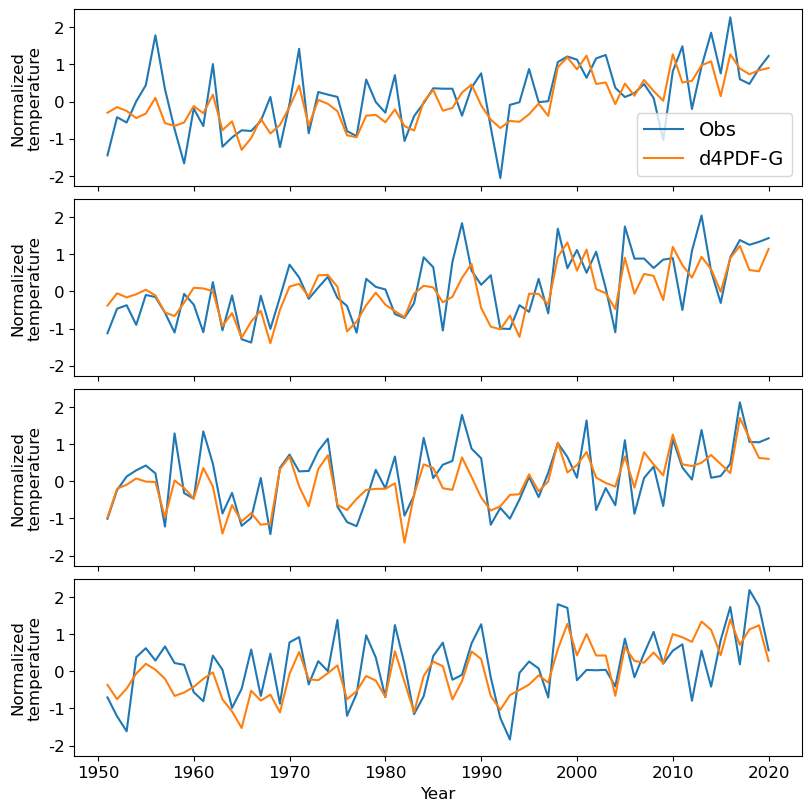

In [64]:
fig,axs = plt.subplots(4,1,figsize=(8,8),layout="constrained",sharex=True,sharey=True)
font['size']=12
label_dict = {'temp':'Obs','TA':'d4PDF-G'}
cmap_v = [0.007,0.001,0.001]

for i,season in enumerate([6,9,12,3]):
    
    ax = axs[i]
    
    for j,df_dict in enumerate([obs_dfs,model_dfs]):
        
        var  = ['temp','TA'][j]

        df = df_dict[var]
        df = df.loc[(df.index.month == season)][time_windows[var][0]:time_windows[var][1]]
        
        df = df.mean(axis=1)
        x = df.index.year.values
        
        ax.plot(x,df.values,label=label_dict[var])
        
    ax.set_yticks([-2,-1,0,1,2])
    ax.set_yticklabels(['-2','-1','0','1','2'],fontdict=font)
    ax.set_ylabel('Normalized\ntemperature',fontdict=font)
    
    if i == 0:
        ax.legend(loc='lower right',fontsize=14)

    if i == 3:
        ax.set_xticks([1950+10*i for i in range(8)])
        ax.set_xticklabels([str(1950+10*i) for i in range(8)],fontdict=font)
        ax.set_xlabel('Year',fontdict=font)
        
font['size']=22

plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/obs_v_model_temp_timeseries.png',dpi=300)

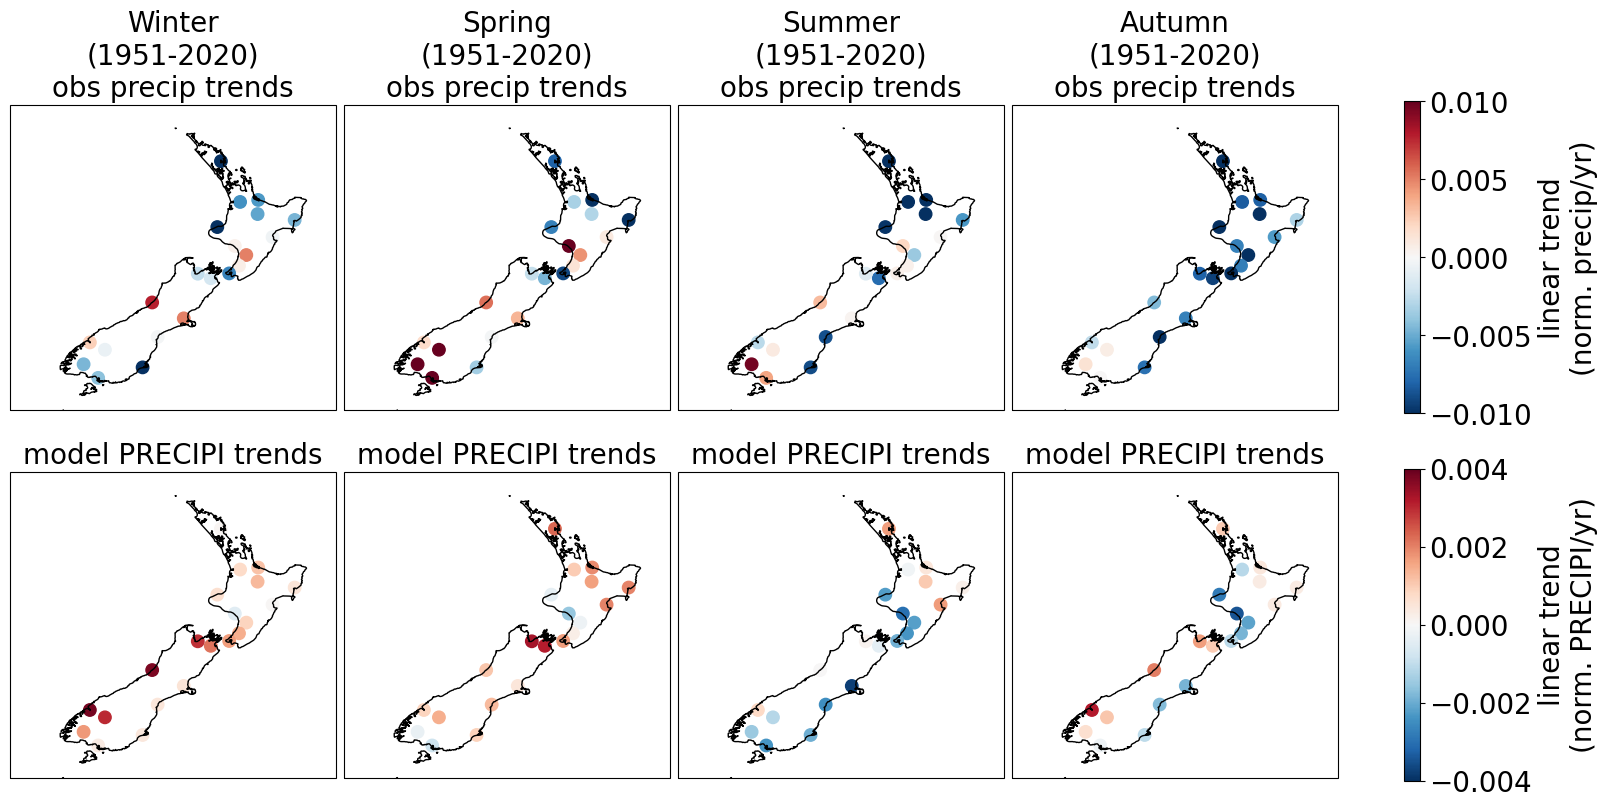

In [74]:
fig,axs = plt.subplots(2,4,figsize=(16,8),subplot_kw=dict(projection=ccrs.PlateCarree()),layout="constrained")

v = 'precipitation'
vrs = vrs_dict[v]

for i,df_dict in enumerate([obs_dfs,model_dfs]):
    
    var  = vrs[i]
    
    for j,season in enumerate([6,9,12,3]):
        
        ax = axs[i][j]
        
        df = df_dict[var]
        df = df.loc[(df.index.month == season)][time_windows[var][0]:time_windows[var][1]]
        
        lats, lons, slopes = get_trend_info(var,df)
        
        im = ax.scatter(lons,lats,c=slopes,cmap='RdBu_r',marker='o',s=80,vmin=-vlim_dict[var],vmax=vlim_dict[var])

        ax.coastlines()
        ax.add_feature(cf.BORDERS)
        ax.set_extent([164,180, -48,-33])#, crs=noproj)
        
        if i == 0:
            ax.set_title(season_dict[season] + '\n(' + time_windows[var][0] + '-' + time_windows[var][1] + ')\nobs ' + var + ' trends',fontsize=20)
        else:
            ax.set_title('model ' + var + ' trends',fontsize=20)


        if j == 3:
            cbar = fig.colorbar(im, ax=axs[i,:])
            cbar.set_label(label='linear trend\n(norm. '+var+'/yr)',size=20)
            cbar.ax.tick_params(labelsize=20)
            
plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/obs_v_model_'+v+'_trend_maps.png',dpi=300)

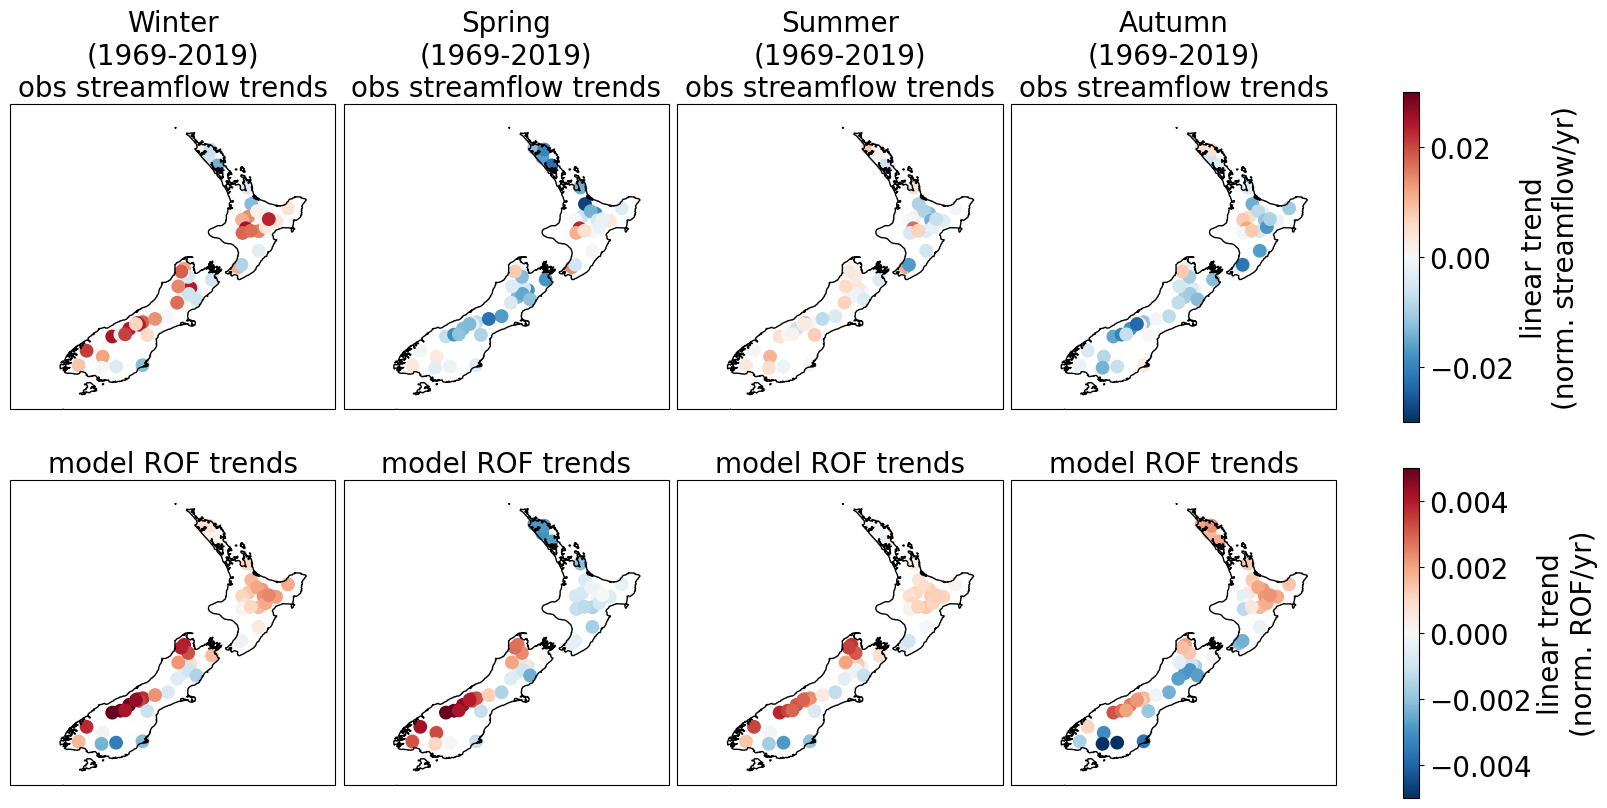

In [75]:
fig,axs = plt.subplots(2,4,figsize=(16,8),subplot_kw=dict(projection=ccrs.PlateCarree()),layout="constrained")

v = 'streamflow'
vrs = vrs_dict[v]

for i,df_dict in enumerate([obs_dfs,model_dfs]):
    
    var  = vrs[i]
    
    for j,season in enumerate([6,9,12,3]):
        
        ax = axs[i][j]
        
        df = df_dict[var]
        df = df.loc[(df.index.month == season)][time_windows[var][0]:time_windows[var][1]]
        
        lats, lons, slopes = get_trend_info(var,df)
        
        im = ax.scatter(lons,lats,c=slopes,cmap='RdBu_r',marker='o',s=80,vmin=-vlim_dict[var],vmax=vlim_dict[var])

        ax.coastlines()
        ax.add_feature(cf.BORDERS)
        ax.set_extent([164,180, -48,-33])#, crs=noproj)
        
        if i == 0:
            ax.set_title(season_dict[season] + '\n(' + time_windows[var][0] + '-' + time_windows[var][1] + ')\nobs ' + var + ' trends',fontsize=20)
        else:
            ax.set_title('model ' + var + ' trends',fontsize=20)


        if j == 3:
            cbar = fig.colorbar(im, ax=axs[i,:])
            cbar.set_label(label='linear trend\n(norm. '+var+'/yr)',size=20)
            cbar.ax.tick_params(labelsize=20)
            
plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/obs_v_model_'+v+'_trend_maps.png',dpi=300)